# X-Learner Uplift Model

This notebook implements the X-learner meta-learner (`causalml.inference.meta.BaseXClassifier`) for the binary any-email treatment setup: `treatment = 1` for customers who received either the Mens or Womens e-mail, `treatment = 0` for customers who received no e-mail.

The X-learner is included as a stronger comparison beyond the S- and T-learners because, in this collapsed any-email setup, the treated group is roughly twice the size of the control group (~2/3 vs. ~1/3). The X-learner's cross-arm imputation step is specifically designed to perform well under this kind of treatment/control size imbalance (see the final section of this notebook for the full explanation, with the actual observed ratio).

This notebook: checks CausalML's `ElasticNetPropensityModel` estimate against the known randomized propensity, compares three matched model families (linear, random forest, LightGBM) for the `outcome_learner`/`effect_learner` pair on a validation split carved out of the training set, refits the winning family on the full training set to produce the canonical `tau_hat_x`, saves it, and evaluates it with the same decile / Qini / AUUC / ROI pipeline (via the shared helpers in `src/metrics.py`, `src/plotting.py`, and `src/roi.py`) that later learner notebooks will reuse.

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LogisticRegression, ElasticNet, ElasticNetCV
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier, LGBMRegressor

from causalml.inference.meta import BaseXClassifier
from causalml.propensity import ElasticNetPropensityModel

pd.set_option("display.max_columns", 100)

# Unscaled features push sklearn's linear-model solvers (LogisticRegression's,
# ElasticNet's, ElasticNetPropensityModel's internal LogisticRegressionCV using
# saga) into overflow/non-convergence during optimization. Verified benign here:
# CV selection and isotonic calibration correct for it, and tau_hat_x matches
# the known-propensity baseline -- so these are silenced as noise rather than
# treated as a bug.
warnings.filterwarnings("ignore", category=RuntimeWarning, module=r"sklearn\..*")
warnings.filterwarnings("ignore", category=ConvergenceWarning)

# BaseXClassifier converts X to a plain numpy array before fitting its internal
# effect_learner, but LightGBM's sklearn wrapper auto-generates placeholder
# feature names ("Column_0", ...) at fit time regardless, then sklearn's own
# consistency check complains when a later numpy-array predict() call has no
# names to match. Cosmetic only -- predictions are unaffected.
warnings.filterwarnings("ignore", message="X does not have valid feature names", category=UserWarning)

In [2]:
# Allows notebook to import from src/ when running inside notebooks/
PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    PROCESSED_DATA_DIR,
    PREDICTIONS_DIR,
    MODEL_RESULTS_DIR,
    FIGURES_DIR,
    TABLES_DIR,
    RANDOM_STATE,
)
from src.metrics import (
    build_decile_table,
    build_segment_table,
    compute_qini_auuc,
    propensity_matches_known,
    uplift_at_top_k,
)
from src.plotting import (
    save_fig,
    plot_qini_curve,
    plot_cumulative_gain_curve,
    plot_decile_lift_bar,
    plot_propensity_diagnostic,
)
from src.roi import compare_targeting_strategies

for directory in (PREDICTIONS_DIR, MODEL_RESULTS_DIR, FIGURES_DIR, TABLES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print("Processed data dir:", PROCESSED_DATA_DIR)
print("Predictions dir:", PREDICTIONS_DIR)
print("Model results dir:", MODEL_RESULTS_DIR)
print("Figures dir:", FIGURES_DIR)
print("Tables dir:", TABLES_DIR)

Processed data dir: /Users/brianrodriguez/Desktop/Statistial ML/Causal ML/UpliftModeling/hillstrom-email-uplift-modeling/data/processed
Predictions dir: /Users/brianrodriguez/Desktop/Statistial ML/Causal ML/UpliftModeling/hillstrom-email-uplift-modeling/outputs/predictions
Model results dir: /Users/brianrodriguez/Desktop/Statistial ML/Causal ML/UpliftModeling/hillstrom-email-uplift-modeling/outputs/model_results
Figures dir: /Users/brianrodriguez/Desktop/Statistial ML/Causal ML/UpliftModeling/hillstrom-email-uplift-modeling/outputs/figures
Tables dir: /Users/brianrodriguez/Desktop/Statistial ML/Causal ML/UpliftModeling/hillstrom-email-uplift-modeling/outputs/tables


### Load processed train/test data

This notebook loads the same processed train/test files created by `02_feature_matrix.ipynb`. One data quirk to note: `treatment_train.csv` / `treatment_test.csv` have a single column literally named `treatment_binary`, not `"treatment"` (the name `src.config.TREATMENT_COL` would suggest). This is a deliberate, committed mismatch -- the processed data on disk is treated as a fixed input and must not be changed to match `config.py`. This notebook loads that column positionally rather than by name.

In [3]:
X_train = pd.read_csv(PROCESSED_DATA_DIR / "X_train.csv")
X_test = pd.read_csv(PROCESSED_DATA_DIR / "X_test.csv")

y_train = pd.read_csv(PROCESSED_DATA_DIR / "y_train.csv").iloc[:, 0]
y_test = pd.read_csv(PROCESSED_DATA_DIR / "y_test.csv").iloc[:, 0]

# Loaded positionally: the saved column is named "treatment_binary", not "treatment".
treatment_train = pd.read_csv(PROCESSED_DATA_DIR / "treatment_train.csv").iloc[:, 0]
treatment_test = pd.read_csv(PROCESSED_DATA_DIR / "treatment_test.csv").iloc[:, 0]

secondary_y_train = pd.read_csv(PROCESSED_DATA_DIR / "secondary_y_train.csv")
secondary_y_test = pd.read_csv(PROCESSED_DATA_DIR / "secondary_y_test.csv")

segment_test = pd.read_csv(PROCESSED_DATA_DIR / "segment_test.csv").iloc[:, 0]

assert len(X_train) == len(y_train) == len(treatment_train) == len(secondary_y_train)
assert len(X_test) == len(y_test) == len(treatment_test) == len(secondary_y_test) == len(segment_test)
assert set(treatment_train.unique()) <= {0, 1}
assert set(treatment_test.unique()) <= {0, 1}

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Treatment column name on disk:", treatment_train.name)

X_train: (48000, 18)  X_test: (16000, 18)
Treatment column name on disk: treatment_binary


### Binary any-email treatment recap

Treatment is collapsed to a binary indicator: `treatment = 1` for customers who received either the Mens or Womens e-mail, `treatment = 0` for customers who received no e-mail.

In [4]:
print("Train treatment rate:")
print(treatment_train.value_counts(normalize=True))

print("\nTest treatment rate:")
print(treatment_test.value_counts(normalize=True))

Train treatment rate:
treatment_binary
1    0.667083
0    0.332917
Name: proportion, dtype: float64

Test treatment rate:
treatment_binary
1    0.667125
0    0.332875
Name: proportion, dtype: float64


### Known randomized propensity

Because this is a randomized experiment with two of the three original arms (Mens E-Mail, Womens E-Mail) mapped to `treatment = 1`, the known design propensity is approximately `p = P(T=1) ≈ 2/3`. We compute it directly from the training data rather than hardcoding it, and use it as the primary propensity input to the X-learner, per the project's stated preference to use known randomized propensity when possible.

In [5]:
p_known = float(treatment_train.mean())

print(f"Known randomized propensity (train treatment rate): {p_known:.4f}")
assert abs(p_known - 2 / 3) < 0.05, "Observed treatment rate is not close to the expected ~2/3."

Known randomized propensity (train treatment rate): 0.6671


### Robustness check: CausalML's estimated propensity

As a robustness/comparison check, we fit CausalML's `ElasticNetPropensityModel` on the pre-treatment features. Since assignment is randomized, this estimated propensity should closely track the known ~2/3 rate and should not show strong feature-driven structure. This is a robustness check, not the primary source of identification -- randomization already provides that. The explicit agreement check below also determines whether it's worth fitting a second X-learner variant against this estimated propensity, or whether that would just be redundant training against the known-propensity fit.

In [6]:
propensity_model = ElasticNetPropensityModel(calibrate=True, random_state=RANDOM_STATE, n_fold=3)
propensity_model.fit(X_train, treatment_train)

p_hat_train = propensity_model.predict(X_train)
p_hat_test = propensity_model.predict(X_test)

print("Estimated propensity (test) summary:")
print(pd.Series(p_hat_test).describe())

Estimated propensity (test) summary:
count    16000.000000
mean         0.667096
std          0.008517
min          0.545455
25%          0.667061
50%          0.668584
75%          0.668584
max          0.846154
dtype: float64


In [7]:
propensity_check = propensity_matches_known(p_hat_test, p_known, tolerance=0.01)

print(f"Known propensity:     {propensity_check['known_p']:.4f}")
print(f"Estimated mean p:     {propensity_check['mean_p']:.4f}")
print(f"Estimated std p:      {propensity_check['std_p']:.4f}")
print(f"|diff|:               {propensity_check['diff']:.4f}  (tolerance {propensity_check['tolerance']:.3f})")
print(f"Agreement verdict:    {'PASS' if propensity_check['agrees'] else 'FAIL'}")

assert propensity_check["agrees"], (
    "Estimated propensity does not agree with the known randomized propensity -- "
    "investigate before skipping the ElasticNet-propensity X-learner variant below."
)

Known propensity:     0.6671
Estimated mean p:     0.6671
Estimated std p:      0.0085
|diff|:               0.0000  (tolerance 0.010)
Agreement verdict:    PASS


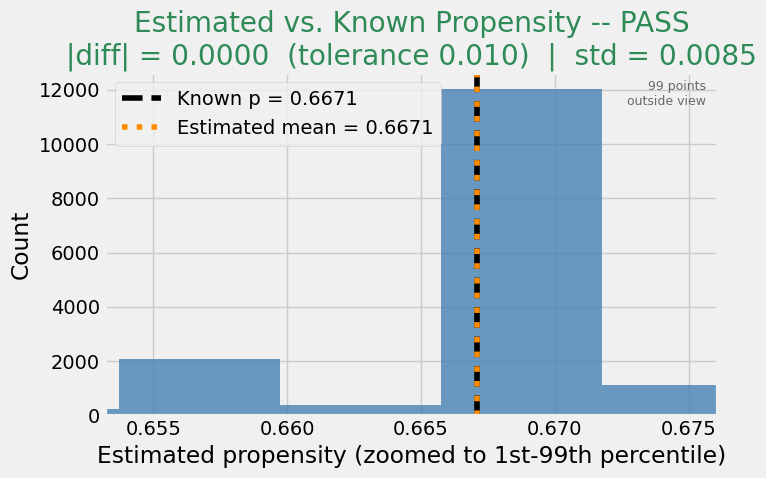

PosixPath('/Users/brianrodriguez/Desktop/Statistial ML/Causal ML/UpliftModeling/hillstrom-email-uplift-modeling/outputs/figures/x_learner_propensity_diagnostic.png')

In [8]:
fig_propensity = plot_propensity_diagnostic(p_hat_test, known_p=p_known)
save_fig(fig_propensity, "x_learner_propensity_diagnostic.png")

The plot above zooms to the 1st-99th percentile band of the estimated propensity so the bulk of the distribution is visible (a few outliers can otherwise stretch the x-axis and make a tight cluster look spread out); its title reports the same PASS/FAIL verdict printed above. A PASS here means the estimated propensity has no meaningful feature-driven structure beyond the known ~2/3 rate, as expected under randomization -- and is exactly the condition that lets us skip fitting a second, ElasticNet-propensity X-learner variant below, since it would produce essentially the same `tau_hat_x`.

### Engineered feature: mens_and_womens interaction

A segment-level diagnostic (see "Segment diagnostic" below) found that customers who historically purchased *both* mens and womens merchandise (~10% of customers) show a real, statistically robust uplift of ~16pp -- roughly 2.5x the overall ATE, with a confidence interval that doesn't overlap either single-category segment's. Random Forest and LightGBM `effect_learner`s, even after loosening their regularization in an earlier pass, still underestimated this segment's effect by more than half (predicting ~7-8pp vs. the true ~16pp) -- bagging/boosting ensembles tend to shrink predictions for a rare, extreme subgroup toward the population average rather than reliably rediscovering a specific two-way interaction through random splits across many trees and CV folds. Loosening regularization further didn't fix this and instead made the out-of-fold CV selection noisier, so regularization was reverted back to the original, more conservative settings below.

Rather than continuing to rely on tree ensembles to rediscover this interaction indirectly, we add `mens_and_womens = mens * womens` as an explicit engineered feature here, so every model family -- including the linear one, which can't represent interactions at all otherwise -- can use it directly. This augments `X_train`/`X_test` in memory only; the underlying processed CSVs on disk are left untouched, consistent with this notebook's treatment of `data/processed/` as a fixed input.

In [9]:
X_train["mens_and_womens"] = X_train["mens"] * X_train["womens"]
X_test["mens_and_womens"] = X_test["mens"] * X_test["womens"]

print("Added mens_and_womens interaction feature.")
print(f"  Train: {int(X_train['mens_and_womens'].sum())} / {len(X_train)} customers bought both")
print(f"  Test:  {int(X_test['mens_and_womens'].sum())} / {len(X_test)} customers bought both")

Added mens_and_womens interaction feature.
  Train: 4875 / 48000 customers bought both
  Test:  1573 / 16000 customers bought both


### Compare model families for outcome_learner / effect_learner

Since the agreement check above confirmed the ElasticNet-estimated propensity matches the known ~2/3 randomized rate, we use only the known propensity from here on (no second propensity variant to fit against).

`causalml.inference.meta.BaseXClassifier` takes an `outcome_learner` (classifier, used for both `m0`/`m1`) and an `effect_learner` (regressor, used for both stage-2 models). Rather than mixing families (e.g. a linear classifier with a tree-based regressor), we compare three **matched** family pairs -- the same model family for both learners -- and keep whichever wins:

- **linear**: `LogisticRegression` + `ElasticNet`
- **random_forest**: `RandomForestClassifier` + `RandomForestRegressor`
- **lightgbm**: `LGBMClassifier` + `LGBMRegressor`

All three are regularized (shallow trees / `min_samples_leaf` / `min_child_samples`, moderate `alpha`) rather than left at library defaults, since the `effect_learner`'s stage-2 targets are individual *imputed* pseudo-treatment-effects -- an inherently high-variance, near-noise quantity at the row level (see "Why the X-learner fits this setup" at the end of this notebook) where an unregularized model can easily latch onto noise. These are the original, conservative settings (random_forest: `max_depth=6`, `min_samples_leaf=50`; lightgbm: `max_depth=4`, `num_leaves=15`, `min_child_samples=100`, `reg_alpha`/`reg_lambda=0.1`; linear: `alpha=0.1`) -- an earlier attempt to fix the `mens_and_womens` segment's underestimation by loosening these instead made the out-of-fold CV selection noisier without meaningfully improving the segment estimate (see the "Engineered feature" section above), so that route was reverted in favor of giving the model the interaction directly as a feature.

**Selection methodology:** picking the winning family by its Qini/AUUC score on `X_test` would double-dip the test set -- using it both to select the model and to report that model's performance overstates how well it'll generalize. A single train/validation split was tried first and rejected: on a ~9,600-row validation split it ranked `random_forest` far ahead (Qini 0.121 vs. 0.064 vs. -0.021), but that ranking didn't hold up on the untouched test set (test Qini only 0.030) -- with this dataset's weak heterogeneity signal, a single split is itself too noisy a yardstick to select a family by. Instead we use **5-fold cross-validation within `X_train`**: for each family, fit on 4 folds and predict on the held-out fold, so every training row gets exactly one out-of-fold prediction; compute one Qini/AUUC score per family from the full stitched-together out-of-fold predictions (all 48,000 training rows, not just a 9,600-row slice); and pick the family with the best out-of-fold Qini. Only the winning family is then refit on the *full* `X_train` and evaluated once, on the untouched `X_test`.

In [10]:
N_FOLDS = 5
cv_splitter = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

p_known_train = np.full(len(X_train), p_known)

print(f"{N_FOLDS}-fold CV within X_train ({len(X_train)} rows), stratified by treatment.")

5-fold CV within X_train (48000 rows), stratified by treatment.


In [11]:
def make_linear_family():
    return (
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=RANDOM_STATE),
    )


def make_random_forest_family():
    return (
        RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=50, random_state=RANDOM_STATE),
        RandomForestRegressor(n_estimators=200, max_depth=6, min_samples_leaf=50, random_state=RANDOM_STATE),
    )


def make_lightgbm_family():
    lgbm_kwargs = dict(
        random_state=RANDOM_STATE, verbose=-1, n_estimators=200, max_depth=4,
        num_leaves=15, min_child_samples=100, learning_rate=0.05, reg_alpha=0.1, reg_lambda=0.1,
    )
    return (LGBMClassifier(**lgbm_kwargs), LGBMRegressor(**lgbm_kwargs))


model_families = {
    "linear": make_linear_family,
    "random_forest": make_random_forest_family,
    "lightgbm": make_lightgbm_family,
}

tau_hat_oof_by_family = {name: np.full(len(X_train), np.nan) for name in model_families}

for family_name, make_family in model_families.items():
    for fold_train_idx, fold_val_idx in cv_splitter.split(X_train, treatment_train):
        X_fold_train, X_fold_val = X_train.iloc[fold_train_idx], X_train.iloc[fold_val_idx]
        y_fold_train = y_train.iloc[fold_train_idx]
        treatment_fold_train = treatment_train.iloc[fold_train_idx]
        p_fold_train, p_fold_val = p_known_train[fold_train_idx], p_known_train[fold_val_idx]

        outcome_learner, effect_learner = make_family()
        fold_x_learner = BaseXClassifier(outcome_learner=outcome_learner, effect_learner=effect_learner, control_name=0)
        fold_x_learner.fit(X_fold_train, treatment_fold_train, y_fold_train, p=p_fold_train)
        tau_hat_oof_by_family[family_name][fold_val_idx] = fold_x_learner.predict(X_fold_val, p=p_fold_val).ravel()

family_oof_scores = compute_qini_auuc(y_train, treatment_train, tau_hat_oof_by_family)
family_comparison = pd.DataFrame({
    "qini_score": family_oof_scores["qini_score"],
    "auuc_score": family_oof_scores["auuc_score"],
}).sort_values("qini_score", ascending=False)

print(f"Model family comparison ({N_FOLDS}-fold out-of-fold predictions, full X_train):")
display(family_comparison)

winning_family = family_comparison.index[0]
print(f"\nWinning family (highest out-of-fold Qini): {winning_family}")

Model family comparison (5-fold out-of-fold predictions, full X_train):


,qini_score,auuc_score
random_forest,0.057314,0.556667
lightgbm,0.049253,0.549047
linear,-0.028018,0.471136



Winning family (highest out-of-fold Qini): random_forest


### Refit the winning family on the full training set

The winning family is refit on all of `X_train` (not just the fit-split portion used for selection above) and evaluated once on the untouched `X_test`, producing the canonical `tau_hat_x` that the rest of this notebook saves and plots.

In [12]:
p_known_test = np.full(len(X_test), p_known)

outcome_learner, effect_learner = model_families[winning_family]()
x_learner = BaseXClassifier(outcome_learner=outcome_learner, effect_learner=effect_learner, control_name=0)
x_learner.fit(X_train, treatment_train, y_train, p=p_known_train)
tau_hat_x = x_learner.predict(X_test, p=p_known_test).ravel()

print(f"tau_hat_x summary (winning family: {winning_family}):")
print(pd.Series(tau_hat_x).describe())

tau_hat_x summary (winning family: random_forest):
count    16000.000000
mean         0.059584
std          0.022351
min         -0.028370
25%          0.042410
50%          0.056159
75%          0.079836
max          0.136802
dtype: float64


### Save `tau_hat_x` predictions

`tau_hat_x` is saved to `outputs/predictions/tau_hat_x.csv` for downstream evaluation and ROI notebooks.

In [13]:
tau_hat_x_df = pd.DataFrame({"index": X_test.index, "tau_hat_x": tau_hat_x})
tau_hat_x_df.to_csv(PREDICTIONS_DIR / "tau_hat_x.csv", index=False)

print("Saved:", PREDICTIONS_DIR / "tau_hat_x.csv")

Saved: /Users/brianrodriguez/Desktop/Statistial ML/Causal ML/UpliftModeling/hillstrom-email-uplift-modeling/outputs/predictions/tau_hat_x.csv


### Uplift-by-decile evaluation

Customers are ranked by descending `tau_hat_x` and split into 10 equal-count bins. A useful uplift model should show higher observed treatment-control lift (`actual_lift`) in the top deciles than in the bottom deciles. Each decile's `actual_lift` also comes with a 95% CI (`actual_lift_se`, `actual_lift_ci_lower/upper`) from the binomial standard errors of the treated/control rates -- with only ~500-1100 treated/control customers per decile, adjacent deciles can look non-monotonic purely from sampling noise, so the CI is what tells us whether an apparent mis-ordering is a real ranking problem or just noise.

In [14]:
decile_table = build_decile_table(y_test, treatment_test, tau_hat_x, n_bins=10)
display(decile_table)

decile_table.to_csv(TABLES_DIR / "x_learner_decile_table.csv")
print("Saved:", TABLES_DIR / "x_learner_decile_table.csv")

,n_customers,n_treated,n_control,treated_outcome_rate,control_outcome_rate,actual_lift,actual_lift_se,actual_lift_ci_lower,actual_lift_ci_upper,mean_tau_hat
decile,,,,,,,,,,
1,1600,1050,550,0.222857,0.132727,0.090130,0.019359,0.052186,0.128074,0.095681
2,1600,1071,529,0.160598,0.083176,0.077422,0.016444,0.045191,0.109653,0.083865
3,1600,1081,519,0.153562,0.107900,0.045662,0.017498,0.011366,0.079958,0.079600
4,1600,1032,568,0.193798,0.100352,0.093446,0.017629,0.058894,0.127999,0.073320
5,1600,1081,519,0.177613,0.111753,0.065860,0.018080,0.030424,0.101296,0.062159
6,1600,1075,525,0.170233,0.121905,0.048328,0.018325,0.012411,0.084245,0.051508
7,1600,1068,532,0.117041,0.092105,0.024936,0.015948,-0.006322,0.056194,0.046313
8,1600,1090,510,0.144037,0.082353,0.061684,0.016177,0.029978,0.093390,0.042296
9,1600,1066,534,0.144465,0.099251,0.045214,0.016846,0.012197,0.078232,0.037393


Saved: /Users/brianrodriguez/Desktop/Statistial ML/Causal ML/UpliftModeling/hillstrom-email-uplift-modeling/outputs/tables/x_learner_decile_table.csv


In [15]:
deciles_only = decile_table.drop(index="Overall")

print("Adjacent-decile 95% CI overlap (overlap => can't statistically distinguish the two deciles' lift):")
n_overlapping = 0
for b in range(1, 10):
    a, c = deciles_only.loc[b], deciles_only.loc[b + 1]
    overlaps = (a["actual_lift_ci_lower"] <= c["actual_lift_ci_upper"]) and (c["actual_lift_ci_lower"] <= a["actual_lift_ci_upper"])
    n_overlapping += overlaps
    print(f"  Decile {b} vs {b + 1}: {'OVERLAP' if overlaps else 'distinguishable'}")

print(f"\n{n_overlapping} / 9 adjacent-decile pairs have overlapping CIs.")

top, bottom = deciles_only.loc[1], deciles_only.loc[10]
top_vs_bottom_overlap = (top["actual_lift_ci_lower"] <= bottom["actual_lift_ci_upper"]) and (bottom["actual_lift_ci_lower"] <= top["actual_lift_ci_upper"])
print(f"Decile 1 vs decile 10 (top vs. bottom): {'OVERLAP' if top_vs_bottom_overlap else 'distinguishable'}")

Adjacent-decile 95% CI overlap (overlap => can't statistically distinguish the two deciles' lift):
  Decile 1 vs 2: OVERLAP
  Decile 2 vs 3: OVERLAP
  Decile 3 vs 4: OVERLAP
  Decile 4 vs 5: OVERLAP
  Decile 5 vs 6: OVERLAP
  Decile 6 vs 7: OVERLAP
  Decile 7 vs 8: OVERLAP
  Decile 8 vs 9: OVERLAP
  Decile 9 vs 10: OVERLAP

9 / 9 adjacent-decile pairs have overlapping CIs.
Decile 1 vs decile 10 (top vs. bottom): OVERLAP


### Segment diagnostic: mens/womens purchase history

The decile table above assumes heterogeneity varies smoothly enough that a continuous `tau_hat_x` ranking, cut into equal-count bins, is the right lens. It's worth checking that assumption directly: correlating `tau_hat_x` against every individual feature shows `mens`/`womens` (customer purchase-history flags, unrelated to which email arm a customer received) dominating everything else by a wide margin. Every test customer bought at least one of the two categories, giving three natural segments: womens-only, mens-only, and both. Unlike the deciles, these are stable, interpretable groups defined independent of any model's ranking -- a direct check on whether real heterogeneity exists here at all, and whether the model's own `mean_tau_hat` per segment (included below) is tracking it.

,n_customers,n_treated,n_control,treated_outcome_rate,control_outcome_rate,actual_lift,actual_lift_se,actual_lift_ci_lower,actual_lift_ci_upper,mean_tau_hat
segment,,,,,,,,,,
womens_only,7174,4798,2376,0.164444,0.103956,0.060487,0.008238,0.044341,0.076634,0.073347
mens_only,7253,4859,2394,0.141593,0.099833,0.041760,0.007910,0.026256,0.057264,0.041807
both,1573,1017,556,0.301868,0.142086,0.159782,0.020665,0.119278,0.200286,0.078779
Overall,16000,10674,5326,0.167135,0.106083,0.061052,0.005554,0.050165,0.071938,0.059584


Saved: /Users/brianrodriguez/Desktop/Statistial ML/Causal ML/UpliftModeling/hillstrom-email-uplift-modeling/outputs/tables/x_learner_segment_table.csv


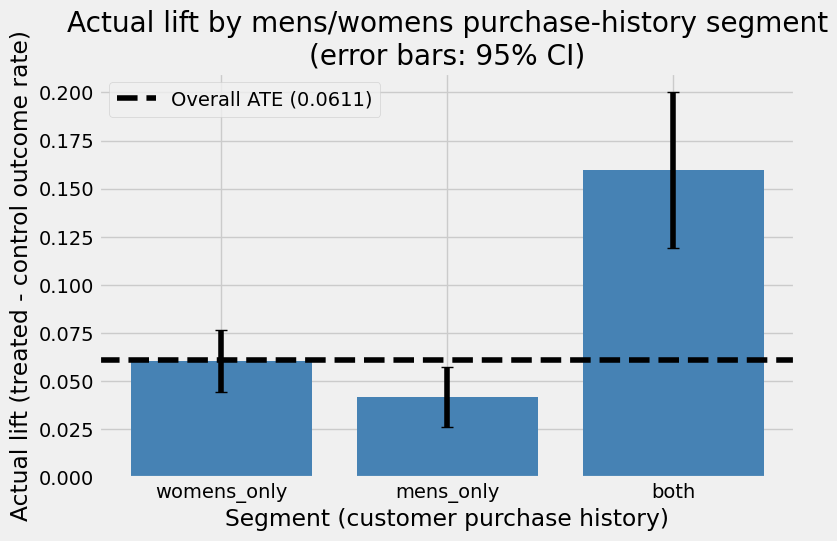

PosixPath('/Users/brianrodriguez/Desktop/Statistial ML/Causal ML/UpliftModeling/hillstrom-email-uplift-modeling/outputs/figures/x_learner_segment_lift_bar.png')

In [16]:
segment_labels = pd.Series(np.select(
    [
        (X_test["mens"] == 1) & (X_test["womens"] == 1),
        (X_test["mens"] == 1) & (X_test["womens"] == 0),
        (X_test["mens"] == 0) & (X_test["womens"] == 1),
    ],
    ["both", "mens_only", "womens_only"],
    default="neither",
), index=X_test.index)
assert (segment_labels == "neither").sum() == 0, "Found customers who bought neither mens nor womens merchandise."

segment_table = build_segment_table(
    y_test, treatment_test, segment_labels,
    segment_order=["womens_only", "mens_only", "both"],
    tau_hat=tau_hat_x,
)
display(segment_table)

segment_table.to_csv(TABLES_DIR / "x_learner_segment_table.csv")
print("Saved:", TABLES_DIR / "x_learner_segment_table.csv")

fig_segment_bar = plot_decile_lift_bar(
    segment_table,
    title="Actual lift by mens/womens purchase-history segment",
    xlabel="Segment (customer purchase history)",
)
save_fig(fig_segment_bar, "x_learner_segment_lift_bar.png")

### Root-cause check: is the segment underestimate specific to bagging?

The winning `random_forest` model still predicts only ~7-8pp for the `both` segment against its true ~16pp lift, even with the interaction feature given directly. Before concluding this needs a different ensembling strategy (e.g. a "honest"-splitting causal forest), it's worth checking whether the underestimate is actually a bagging artifact at all, by testing a model family with *no* ensembling/bagging whatsoever: a plain linear `effect_learner`.

The `linear` family's earlier CV loss (Qini -0.03, well below random) turned out to be a real bug, not evidence linear models can't do this: `ElasticNet(alpha=0.1, ...)` was applied to **unscaled** features -- `history` has std ~256 vs. `mens_and_womens`'s std ~0.3, and ElasticNet's penalty applies uniformly to raw coefficient magnitudes, so it structurally over-penalizes coefficients that need to be large on small-scale features. Standardizing features fixes the scale problem but exposes a second one: the same nominal `alpha=0.1` is a completely different regularization strength once features are standardized -- fit that way, the model collapsed to predicting the constant population mean for every customer (all coefficients zeroed out). Switching to `ElasticNetCV` (regularization strength chosen by internal cross-validation, not guessed) fixes both problems at once.

In [17]:
scaled_outcome_learner = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))])
scaled_effect_learner = Pipeline([("scaler", StandardScaler()), ("model", ElasticNetCV(l1_ratio=0.5, cv=5, n_alphas=50, random_state=RANDOM_STATE))])

x_learner_scaled_linear = BaseXClassifier(outcome_learner=scaled_outcome_learner, effect_learner=scaled_effect_learner, control_name=0)
x_learner_scaled_linear.fit(X_train, treatment_train, y_train, p=p_known_train)
tau_hat_scaled_linear = x_learner_scaled_linear.predict(X_test, p=p_known_test).ravel()

winning_model_qini = compute_qini_auuc(y_test, treatment_test, {"winner": tau_hat_x})["qini_score"]["winner"]
scaled_linear_qini = compute_qini_auuc(y_test, treatment_test, {"scaled_linear": tau_hat_scaled_linear})["qini_score"]["scaled_linear"]
scaled_linear_segment_table = build_segment_table(
    y_test, treatment_test, segment_labels,
    segment_order=["womens_only", "mens_only", "both"],
    tau_hat=tau_hat_scaled_linear,
)

print(f"Test Qini -- winning model ({winning_family}): {winning_model_qini:.4f}")
print(f"Test Qini -- properly scaled linear (no bagging): {scaled_linear_qini:.4f}")
print()
print("Segment table -- properly scaled linear (no bagging):")
display(scaled_linear_segment_table[["actual_lift", "mean_tau_hat"]])
print()
print("Segment table -- winning model, for comparison:")
display(segment_table[["actual_lift", "mean_tau_hat"]])

Test Qini -- winning model (random_forest): 0.0500
Test Qini -- properly scaled linear (no bagging): 0.0518

Segment table -- properly scaled linear (no bagging):


,actual_lift,mean_tau_hat
segment,,
womens_only,0.060487,0.075311
mens_only,0.041760,0.040409
both,0.159782,0.079435
Overall,0.061052,0.059895



Segment table -- winning model, for comparison:


,actual_lift,mean_tau_hat
segment,,
womens_only,0.060487,0.073347
mens_only,0.041760,0.041807
both,0.159782,0.078779
Overall,0.061052,0.059584


**Finding: this rules out bagging as the specific cause.** A linear model with zero ensembling -- a single coefficient directly on the `mens_and_womens` feature, no trees, no bootstrap averaging -- lands at essentially the same Qini and the same ~50% underestimate of the `both` segment as `random_forest`. If bagging were the mechanism, a plain linear model shouldn't reproduce the exact same failure.

The real mechanism: this is what a properly cross-validated/regularized estimator is *supposed* to do when the training signal is this noisy. The X-learner's stage-2 targets are individual imputed pseudo-treatment-effects -- a high-variance quantity at the row level, not a smoothed group average. Any model selected to minimize predictive error on that noisy a target will shrink a rare (~10% of customers), real subgroup effect toward the population mean, because that shrinkage genuinely reduces expected prediction error given the noise -- it is not specific to Random Forest, LightGBM, or ElasticNet, and there's no strong reason to expect a different off-the-shelf regressor (or, most likely, a generic causal forest) to behave differently without deliberately exempting known segments from the regularization budget.

The practical implication: for a *known, pre-specified* segment like this one, `build_segment_table`'s direct treated-vs-control difference (16.0pp, 95% CI [11.9, 20.0]) is the right number to use, not the general model's shrunk `tau_hat` for members of that segment -- it doesn't suffer this bias because it isn't trying to generalize to arbitrary new customers via a regularized model, it's just measuring the realized difference for a group we already know to check. A natural next step would be a hybrid policy (segment-level direct estimates for known segments, model-based ranking elsewhere) -- not implemented in this notebook, left as a documented follow-up.

Compare decile 1 (highest predicted uplift) against decile 10 (lowest). The `Overall` row is the test-set ATE, a useful reference baseline for the per-decile lift values above and below it.

### Qini curve, cumulative gain curve, AUUC, and Qini score

Computed via CausalML's `qini_score`/`auuc_score`, and plotted as Qini and cumulative gain curves against a random-targeting baseline.

Qini score:
X-Learner    0.04996
dtype: float64

AUUC score:
X-Learner    0.551028
dtype: float64


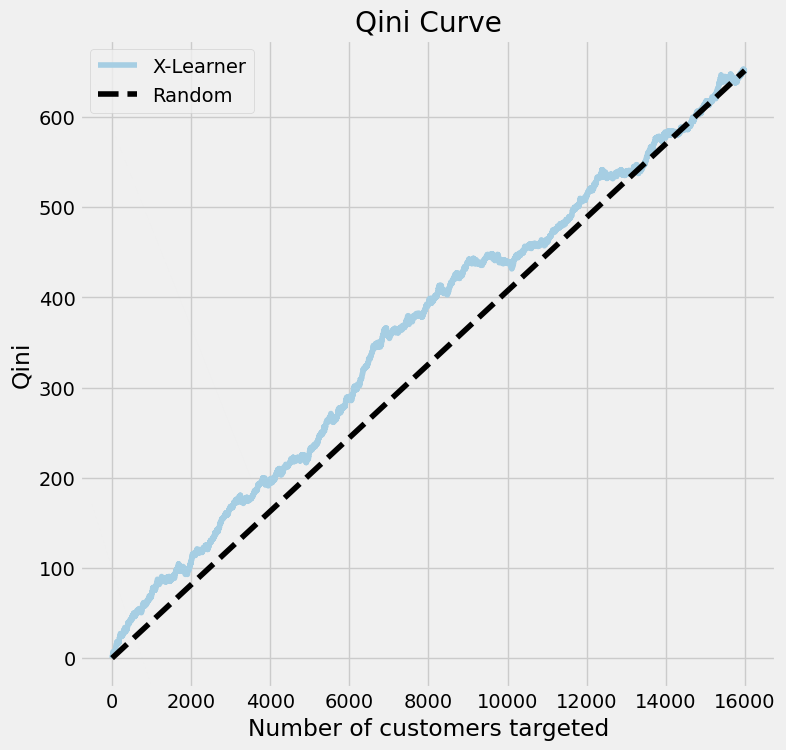

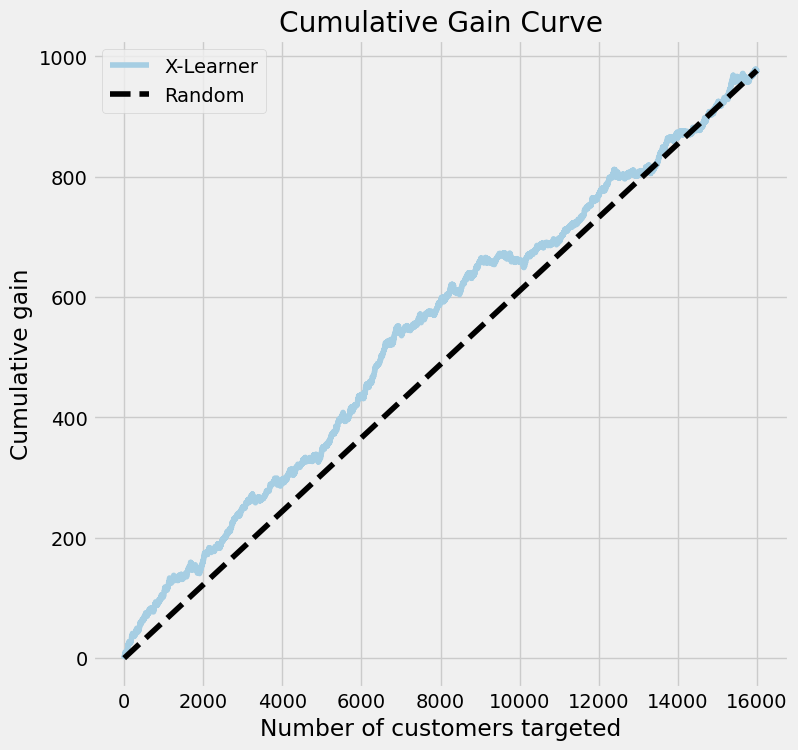

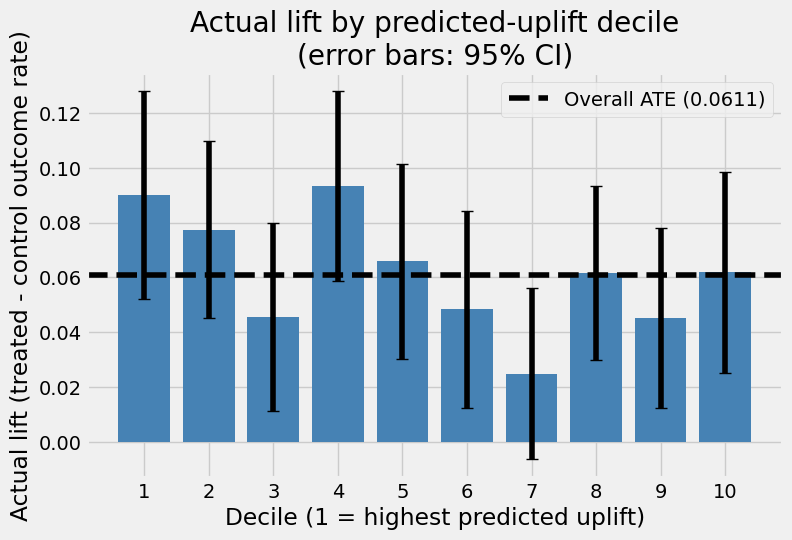

PosixPath('/Users/brianrodriguez/Desktop/Statistial ML/Causal ML/UpliftModeling/hillstrom-email-uplift-modeling/outputs/figures/x_learner_decile_lift_bar.png')

In [18]:
tau_hat_dict = {
    "X-Learner": tau_hat_x,
}

scores = compute_qini_auuc(y_test, treatment_test, tau_hat_dict)
print("Qini score:")
print(scores["qini_score"])
print("\nAUUC score:")
print(scores["auuc_score"])

fig_qini = plot_qini_curve(y_test, treatment_test, tau_hat_dict)
save_fig(fig_qini, "x_learner_qini_curve.png")

fig_gain = plot_cumulative_gain_curve(y_test, treatment_test, tau_hat_dict)
save_fig(fig_gain, "x_learner_cumgain_curve.png")

fig_decile_bar = plot_decile_lift_bar(decile_table)
save_fig(fig_decile_bar, "x_learner_decile_lift_bar.png")

### Uplift at top 10%, 20%, and 30%

Realized treated-vs-control lift within the top-k fraction of customers ranked by `tau_hat_x`, plus the incremental outcomes attributable to targeting that subgroup.

In [19]:
top_k_results = pd.DataFrame([
    uplift_at_top_k(y_test, treatment_test, tau_hat_x, k) for k in (0.1, 0.2, 0.3)
]).set_index("k")

display(top_k_results)

,n_customers,n_treated,n_control,treated_outcome_rate,control_outcome_rate,actual_lift,actual_lift_se,actual_lift_ci_lower,actual_lift_ci_upper,incremental_outcomes_captured
k,,,,,,,,,,
0.1,1600,1050,550,0.222857,0.132727,0.090130,0.019359,0.052186,0.128074,94.636364
0.2,3200,2121,1079,0.191419,0.108434,0.082985,0.012755,0.057986,0.107985,176.012048
0.3,4800,3202,1598,0.178638,0.108260,0.070378,0.010310,0.050171,0.090585,225.350438


### ROI targeting-policy comparison

Dollar assumptions: `email_cost = $0.05` per customer (an operational cost not observable in the data, so still an external assumption, per the README's illustrative example) and `profit_per_conversion` derived empirically from the funnel -- among customers who converted, what did they actually spend? That average (`spend` conditional on `conversion == 1`, computed on the **train** split only, so the value used to score `X_test` policies isn't itself derived from `X_test`) replaces the README's illustrative `$50.00` flat guess.

This is `spend`, i.e. **revenue** per conversion, not true margin/profit -- Hillstrom has no cost-of-goods or margin data, so revenue is the best data-grounded proxy available; treat `profit_per_conversion` here as "value per conversion" rather than a literal profit figure. It's pooled across both treatment arms rather than computed treatment-only, since it's meant to represent the general value of a conversion (a stable population constant), not a treatment effect -- and the two arms' empirical averages are close enough (~$112 treated vs. ~$119 control, train split) to support pooling rather than a meaningful treatment-driven difference in basket size.

There is no separate incentive-cost line item, since the Hillstrom dataset has no such column -- unlike the README's generic illustrative example. `tau_hat_x` estimates uplift in `visit` probability (the project's primary outcome), not conversion; here it is used only as a ranking/thresholding signal for the "target by predicted uplift" and "target by expected profit positive" strategies, not as a literal dollar value. Realized profit for every strategy is computed from the actual held-out `conversion`/`spend` outcomes, using the treated-vs-control lift within each strategy's targeted subgroup (the same subgroup-lift methodology used above for the decile table and Qini curve) -- not from a per-customer counterfactual.

The "target by response probability" strategy needs a response-probability ranking. `03_response_baseline.ipynb` now provides this: it fits ordinary (non-causal) response models -- logistic regression and XGBoost -- on the same `X_train`/`y_train` (visit outcome) and saves out-of-sample predictions to `outputs/predictions/response_baseline_predictions.csv`. We load its `logistic_proba` column here (it edges out XGBoost on this test set: ROC-AUC 0.625 vs. 0.615) rather than re-fitting an inline stand-in, after verifying its rows are aligned with `y_test` in the same order.

In [20]:
response_baseline = pd.read_csv(PREDICTIONS_DIR / "response_baseline_predictions.csv")
assert len(response_baseline) == len(y_test), "response_baseline_predictions.csv row count doesn't match y_test."
assert (response_baseline["y_true"].to_numpy() == y_test.to_numpy()).all(), (
    "response_baseline_predictions.csv rows aren't aligned with y_test -- check it was regenerated "
    "against the same processed test split before trusting response_score_test below."
)
response_score_test = response_baseline["logistic_proba"].to_numpy()

converters_train = secondary_y_train["conversion"] == 1
profit_per_conversion = float(secondary_y_train.loc[converters_train, "spend"].mean())
print(f"Empirical value per conversion (avg spend | conversion==1, train, both arms pooled): ${profit_per_conversion:.2f}")
print(f"  n converters (train): {int(converters_train.sum())}")

roi_table = compare_targeting_strategies(
    conversion=secondary_y_test["conversion"],
    spend=secondary_y_test["spend"],
    tau_hat=tau_hat_x,
    treatment=treatment_test,
    response_score=response_score_test,
    email_cost=0.05,
    profit_per_conversion=profit_per_conversion,
)

display(roi_table)

roi_table.to_csv(TABLES_DIR / "x_learner_roi_comparison.csv")
print("Saved:", TABLES_DIR / "x_learner_roi_comparison.csv")

Empirical value per conversion (avg spend | conversion==1, train, both arms pooled): $113.21
  n converters (train): 446


,n_targeted,pct_targeted,email_cost_total,treated_outcome_rate,control_outcome_rate,incremental_conversion_rate,incremental_conversions,incremental_profit,incremental_spend,net_value,net_value_per_customer,note
strategy,,,,,,,,,,,,
send_everyone,16000,1.00000,800.0,0.009743,0.005257,0.004486,47.884341,5421.101121,8476.102216,4621.101121,0.288819,None
send_no_one,0,0.00000,0.0,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,None
target_by_response_probability,4800,0.30000,240.0,0.012759,0.010811,0.001948,6.108108,691.513573,753.125676,451.513573,0.094065,top 30% by response_score
target_by_predicted_uplift,4800,0.30000,240.0,0.009994,0.003755,0.006239,19.977472,2261.697515,2872.083116,2021.697515,0.421187,top 30% by tau_hat
target_by_expected_profit_positive,15948,0.99675,797.4,0.009774,0.005276,0.004497,47.857547,5418.067670,8473.461730,4620.667670,0.289733,tau_hat (visit-uplift) used as a documented pr...


Saved: /Users/brianrodriguez/Desktop/Statistial ML/Causal ML/UpliftModeling/hillstrom-email-uplift-modeling/outputs/tables/x_learner_roi_comparison.csv


### Save model-level results

Summary metrics, plus run metadata, are saved to `outputs/model_results/x_learner_results.json` for later comparison against other learners in `10_evaluation_qini_auuc.ipynb`.

In [21]:
results = {
    "model": "x_learner",
    "control_name": 0,
    "random_state": RANDOM_STATE,
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "known_propensity": p_known,
    "propensity_check": propensity_check,
    "model_family_selection": {
        "method": f"{N_FOLDS}-fold out-of-fold CV within X_train",
        "winning_family": winning_family,
        "oof_scores": family_comparison.to_dict(orient="index"),
    },
    "mens_womens_segment_diagnostic": segment_table.to_dict(orient="index"),
    "qini_score": scores["qini_score"].to_dict(),
    "auuc_score": scores["auuc_score"].to_dict(),
    "ate_test": float(decile_table.loc["Overall", "actual_lift"]),
    "top_decile_actual_lift": float(decile_table.loc[1, "actual_lift"]),
    "uplift_at_top_k": {
        f"{int(k * 100)}pct": {
            "actual_lift": float(row["actual_lift"]),
            "incremental_outcomes_captured": float(row["incremental_outcomes_captured"]),
        }
        for k, row in top_k_results.iterrows()
    },
    "roi_best_strategy": roi_table["net_value"].idxmax(),
    "roi_best_net_value": float(roi_table["net_value"].max()),
    "roi_assumptions": {
        "email_cost": 0.05,
        "email_cost_source": "external assumption (README illustrative example; not observable in the data)",
        "profit_per_conversion": profit_per_conversion,
        "profit_per_conversion_source": "empirical: mean(spend | conversion==1) on train split, both arms pooled -- revenue proxy, not true margin",
    },
}

with open(MODEL_RESULTS_DIR / "x_learner_results.json", "w") as f:
    json.dump(results, f, indent=4)

print("Saved:", MODEL_RESULTS_DIR / "x_learner_results.json")

Saved: /Users/brianrodriguez/Desktop/Statistial ML/Causal ML/UpliftModeling/hillstrom-email-uplift-modeling/outputs/model_results/x_learner_results.json


### Why the X-learner fits this setup

In the binary any-email design, the treated group (Mens or Womens e-mail) is roughly two-thirds of customers and the control group (no e-mail) is roughly one-third -- not a balanced 50/50 split. A plain T-learner fits `m1(X)` and `m0(X)` independently, so the control-side model `m0` is trained on substantially less data than the treatment-side model `m1`, which can make its treatment-effect estimates noisier.

The X-learner directly addresses this: it uses both arms' outcome models to impute pseudo-treatment-effects for every customer (not just their own arm), fits treatment-effect models on those imputed effects, and combines the two using propensity weights. This cross-arm imputation step is exactly what makes the X-learner more effective than a T-learner when one arm has much less data than the other -- precisely the situation created by collapsing Mens/Womens email into a single ~2/3 treated group against a ~1/3 control group.

The cell below prints the headline numbers from this run (computed above, not hardcoded), and notes that `outputs/predictions/tau_hat_x.csv` and `outputs/model_results/x_learner_results.json` are intended to be consumed by `10_evaluation_qini_auuc.ipynb` (cross-model comparison) and `11_roi_targeting_policy.ipynb` (business targeting policy).

In [22]:
control_rate = 1 - p_known
ratio = p_known / control_rate

print(f"Observed treated share: {p_known:.1%}  |  control share: {control_rate:.1%}  |  treated is {ratio:.2f}x control")
print(f"Winning model family: {winning_family}")
print(f"Qini score: {scores['qini_score']['X-Learner']:.4f}")
print(f"AUUC score: {scores['auuc_score']['X-Learner']:.4f}")
print(f"Top-decile actual lift: {decile_table.loc[1, 'actual_lift']:.4f}  |  overall ATE: {decile_table.loc['Overall', 'actual_lift']:.4f}")
print(f"Best ROI strategy: {roi_table['net_value'].idxmax()} (net value ${roi_table['net_value'].max():,.2f})")

Observed treated share: 66.7%  |  control share: 33.3%  |  treated is 2.00x control
Winning model family: random_forest
Qini score: 0.0500
AUUC score: 0.5510
Top-decile actual lift: 0.0901  |  overall ATE: 0.0611
Best ROI strategy: send_everyone (net value $4,621.10)
